***Manga originated Animation vs Anime Studio originated Animation & its global expansion potential*** 

In [26]:
#libraries 
import requests
import pandas as pd 
import time 
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import numpy as np

In [427]:
#Machine Learning libraries *
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

***DataFrame for Manga originated title success from Jikan API*** 

Jikan API : 
Web Scraping of https://myanimelist.net/, which is the world’s largest online database and social community dedicated to Japanese animation (Anime) and comics (Manga). 

I am utilizing the Jikan API to extract Manga-specific metadata first. 

Key features for successful Manga based IP parameters include :
-  Serialization (Jump/Jump+) 
-  Genre
-  Popularity metrics (Members and Favorites)
-  Score
-  Streaming
-  Award 

In [3]:
#Manga DataFrame
#Reading the JikanAPI to see if the call is successful 
jikan_url = "http://discord.jikan.moe"
response = requests.get (jikan_url)
response.status_code

200

In [4]:
#Manga DataFrame
#Testing the API call with 3 Intellectual Property Hits; One Piece, Kimetsu no Yaiba (Demon Slayers), Dandadan 
def get_manga_info(manga_id):
    url = f"https://api.jikan.moe/v4/manga/{manga_id}/full"
    
    try:
        response = requests.get(url)
        
        if response.status_code != 200:
            print(f"Server Error for ID {manga_id}: {response.status_code}")
            return None
            
        if not response.text.strip():
            print(f"Empty envelope for ID {manga_id}. The server sent nothing.")
            return None
            
        return response.json()['data']
        
    except Exception as e:
        print(f"Connection error for ID {manga_id}: {e}")
        return None

ids = [13, 96792, 135496] # One Piece, Demon Slayer, Dandadan
manga_results = []

for m_id in ids:
    data = get_manga_info(m_id)
    if data:
        manga_results.append(data)
        print(f"Successfully pulled: {data['title']}")
    
    # wait 2 seconds before running it again 
    time.sleep(2)

Successfully pulled: One Piece
Successfully pulled: Kimetsu no Yaiba
Successfully pulled: Dandadan


In [5]:
#Manga DataFrame
#Checking the table conversion with the newest Manga based IP hit, Dandadan 
m_id = 135496
url = f"https://api.jikan.moe/v4/manga/{m_id}/full"

response = requests.get(url)

manga_data = [] 

# 3. THE SAFETY CHECK
if response.status_code == 200:
    try:
        # Try to get the JSON
        json_payload = response.json()
        item = json_payload['data']
        
        # specifying the columns
        row = {
            'Manga_ID': item.get('mal_id'),
            'Title' : item.get('title'), 
            'Score' : item.get('score'),
            'Reach_Members': item.get('members'),
            'Loyalty_Favourites':item.get('favorites'),
            'Synopsis' : item.get('synopsis'),
            'Background' : item.get('background'), 
            'Comic Mag' : item.get ('serializations'),
            'Main_Genre' : item['genres'][0]['name'] if item['genres'] else 'N/A'
        }
        
        # appending the API responses into manga_data tuple, checking if it worked 
        manga_data.append(row) 
        print(f"Successfully grabbed: {item.get('title')}")
        
    except Exception as e:
        print(f"JSON Error: {e}")
else:
    print(f"API Error! Status Code: {response.status_code}")
    print("Wait 1 minute and try again. You might be rate-limited.")

manga_df = pd.DataFrame(manga_data) #converting it into dataframe 
manga_df

Successfully grabbed: Dandadan


,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Main_Genre
0,135496,Dandadan,8.44,207058,10870,"After being aggressively rejected, Momo Ayase ...",Dandadan ranked fourth in the 2022 Kono Manga ...,"[{'mal_id': 1209, 'type': 'manga', 'name': 'Sh...",Action


In [6]:
#Manga DataFrame
#Collecting 1000 Manga Titles data that includes useful features of its IP success from Jikan API  
manga_data = []
target_count = 1000
page = 1

print("Starting Manga Data Collection...")

while len(manga_data) < target_count:
    url = f"https://api.jikan.moe/v4/top/manga?page={page}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json().get('data', [])
        
        for item in data:
            if len(manga_data) >= target_count:
                break
                
            row = {
                'Manga_ID': item.get('mal_id'),
                'Title' : item.get('title'), 
                'Score' : item.get('score'),
                'Reach_Members': item.get('members'),
                'Loyalty_Favourites': item.get('favorites'),
                'Synopsis' : item.get('synopsis'),
                'Background' : item.get('background'), 
                'Comic Mag' : item['serializations'][0]['name'] if item.get('serializations') else 'N/A', #'Main_Genre' : item['genres'][0]['name'] if item.get('genres') else 'N/A'
                'Genres' : ", ".join([g['name'] for g in item.get('genres', [])]) if item.get('genres') else 'N/A'
            }
            manga_data.append(row)
        
        print(f"✅ Page {page} done. Total Collected: {len(manga_data)}")
        page += 1
        time.sleep(1) #mitigation for 429 errors
        
    elif response.status_code == 429:
        print("⏳ Rate limited! Waiting 30 seconds...")
        time.sleep(30)
    else:
        print(f"❌ Error {response.status_code}. Stopping.")
        break

# Turn into DataFrame
manga_df = pd.DataFrame(manga_data)

# Saving this on csv 
manga_df.to_csv('top_manga_dataset.csv', index=False)
print("Data saved to 'top_manga_dataset.csv'!")

Starting Manga Data Collection...
✅ Page 1 done. Total Collected: 25
✅ Page 2 done. Total Collected: 50
✅ Page 3 done. Total Collected: 75
✅ Page 4 done. Total Collected: 100
✅ Page 5 done. Total Collected: 125
✅ Page 6 done. Total Collected: 150
✅ Page 7 done. Total Collected: 175
✅ Page 8 done. Total Collected: 200
✅ Page 9 done. Total Collected: 225
✅ Page 10 done. Total Collected: 250
✅ Page 11 done. Total Collected: 275
✅ Page 12 done. Total Collected: 300
✅ Page 13 done. Total Collected: 325
✅ Page 14 done. Total Collected: 350
✅ Page 15 done. Total Collected: 375
✅ Page 16 done. Total Collected: 400
✅ Page 17 done. Total Collected: 425
✅ Page 18 done. Total Collected: 450
✅ Page 19 done. Total Collected: 475
✅ Page 20 done. Total Collected: 500
✅ Page 21 done. Total Collected: 525
✅ Page 22 done. Total Collected: 550
✅ Page 23 done. Total Collected: 575
✅ Page 24 done. Total Collected: 600
✅ Page 25 done. Total Collected: 625
✅ Page 26 done. Total Collected: 650
✅ Page 27 done. 

In [423]:
#Manga DataFrame
#Further refining and filtering the table with success factors such as language translations, award, streaming

#Column that list translated languages 
target_languages = ['English', 'Korean', 'Malay', 'Indonesian', 'Chinese', 'Thai', 'Vietnamese', 'German', 'French', 'Italian', 'Spanish', 'Portuguese', 'Swedish', 'Danish', 'Norwegian', 'Finnish', 'Polish', 'Turkish', 'Russian']
def check_language(text):
    if not text : 
        return "None"
    found = [lang for lang in target_languages if lang in text]
    return ", ".join(found) if found else "None"
manga_df['Languages'] = manga_df ['Background'].apply(check_language) 
manga_df['Language_count'] = manga_df['Languages'].apply(lambda x: 0 if x == 'None' else len (x.split (',')))

#Column that check if any award was given  
award_keywords = ['award', 'Award', 'prize', 'winner', 'finalist']
def check_award(text):
    if not text : 
        return "None"
    found = [word for word in award_keywords if word in text]
    return ", ".join(found) if found else "None"
manga_df['Award_Types'] = manga_df ['Background'].apply(check_award) 
manga_df['Award_count'] = manga_df['Award_Types'].apply(lambda x: 0 if x == 'None' else len (x.split (',')))

#Column that check if it's available in streaming services 
streaming = ['amazon', 'netflix', 'crunchroll', 'viz', 'manga plus']
def check_streaming(text):
    if not text : 
        return "None"
    found = [s for s in streaming if s in text.lower()]
    return ", ".join(found) if found else "None"
manga_df['Streaming'] = manga_df ['Background'].apply(check_streaming) 
manga_df['Streaming_count'] = manga_df['Streaming'].apply(lambda x: 0 if x == 'None' else len (x.split (',')))
manga_df.head(3)

,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Genres,Languages,Language_count,Award_Types,Award_count,Streaming,Streaming_count,Match,Matched_Anime_Title,merge_key,Title_Clean
0,2,Berserk,9.47,782201,136664,"Guts, a former mercenary now known as the Blac...",Berserk won the Excellence Award at the sixth ...,Young Animal,"Action, Adventure, Award Winning, Drama, Fanta...","English, Thai, German",3,Award,1,None,0,105.0,Kenpuu Denki Berserk,berserk,berserk
1,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,9.33,310897,50371,"In the American Old West, the world's greatest...",JoJo no Kimyou na Bouken Part 7: Steel Ball Ru...,Ultra Jump,"Action, Adventure, Mystery, Supernatural",English,1,None,0,viz,1,NaN,None,jojonokimyounaboukensteelballrun,jojo no kimyou na bouken part 7: steel ball run
2,656,Vagabond,9.27,448025,47914,"In 16th-century Japan, Shinmen Takezou is a wi...",Vagabond won the Japan Media Arts Festival Man...,Morning,"Action, Adventure, Award Winning","English, Portuguese",2,Award,1,viz,1,NaN,None,vagabond,vagabond


In [8]:
#Manga DataFrame 
#Sorting the table by first streaming count, as this will be many if the title has profitable success
#loyalty favourites also will tell the impact of the global IP success 
#Score is rated by 
top_manga = manga_df.sort_values(by=['Streaming_count', 'Loyalty_Favourites','Score'], ascending=False)

# View the top 5 to analyse the pattern 
top_manga.head(5)

,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Genres,Languages,Language_count,Award_Types,Award_count,Streaming,Streaming_count
3,13,One Piece,9.22,686782,124999,"Gol D. Roger, a man referred to as the King of...",One Piece is the highest-selling manga series ...,Shounen Jump (Weekly),"Action, Adventure, Fantasy","English, Korean, Malay, Indonesian, Chinese, T...",19,"Award, finalist",2,"netflix, viz, manga plus",3
65,116778,Chainsaw Man,8.69,710754,90054,Denji has a simple dream—to live a happy and p...,Chainsaw Man ranked fourth and first in the 20...,Shounen Jump+,"Action, Award Winning, Fantasy","English, German, Italian",3,Award,1,"viz, manga plus",2
499,113138,Jujutsu Kaisen,8.19,496127,33782,"Hidden in plain sight, an age-old conflict rag...","As a part of the JUMP START initiative, the fi...",Shounen Jump (Weekly),"Action, Supernatural","English, Portuguese, Polish",3,None,0,"viz, manga plus",2
50,26,Hunter x Hunter,8.77,307653,26273,"""Secret treasure hoards, undiscovered wealth.....","As of July 2022, over 84 million copies of Hun...",Shounen Jump (Weekly),"Action, Adventure, Fantasy","English, Italian, Spanish, Portuguese, Polish",5,None,0,"viz, manga plus",2
579,100128,Yakusoku no Neverland,8.14,332299,20588,"At Grace Field House, life could not be better...",Yakusoku no Neverland ranked first in the 2018...,Shounen Jump (Weekly),"Award Winning, Mystery, Suspense","English, Spanish, Portuguese, Polish",4,Award,1,"viz, manga plus",2


C:\Users\akoki\AppData\Local\Temp\ipykernel_16168\4022253531.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.values, y=language_counts.index, palette="magma")


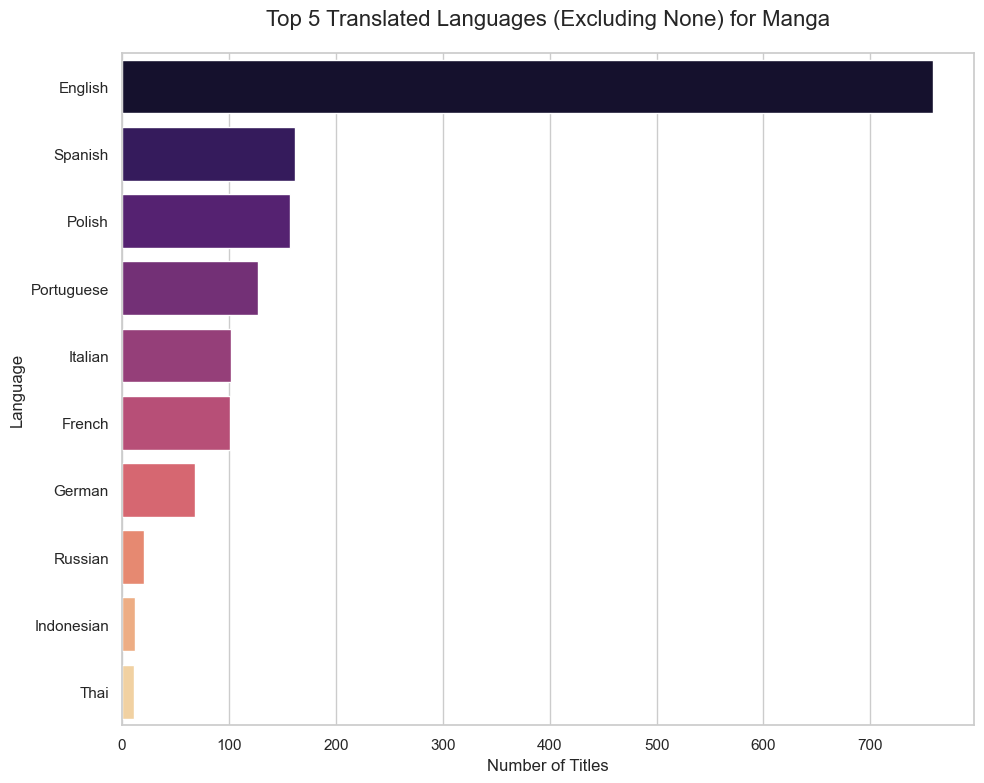

In [274]:
#Filtering English and None out 
all_langs = manga_df['Languages'].str.split(',').explode().str.strip()
excluded = ['None']
langs_filtered = all_langs[~all_langs.isin(excluded)].dropna()

#Top 10
language_counts = langs_filtered.value_counts().head(10)

# 3. Create the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")


sns.barplot(x=language_counts.values, y=language_counts.index, palette="magma")

plt.title('Top 5 Translated Languages (Excluding None) for Manga', fontsize=16, pad=20)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Language', fontsize=12)

plt.tight_layout()
plt.show()

In [9]:
#Manga Dataframe 
#Checking the data types just in case, incredible non-null value and no surprises
manga_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manga_ID            1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Score               1000 non-null   float64
 3   Reach_Members       1000 non-null   int64  
 4   Loyalty_Favourites  1000 non-null   int64  
 5   Synopsis            995 non-null    object 
 6   Background          995 non-null    object 
 7   Comic Mag           1000 non-null   object 
 8   Genres              1000 non-null   object 
 9   Languages           1000 non-null   object 
 10  Language_count      1000 non-null   int64  
 11  Award_Types         1000 non-null   object 
 12  Award_count         1000 non-null   int64  
 13  Streaming           1000 non-null   object 
 14  Streaming_count     1000 non-null   int64  
dtypes: float64(1), int64(6), object(8)
memory usage: 117.3+ 

In [10]:
#[Manga Dataframe] 
#[Exploratory Data Analysis]

#Getting a quick feel of the Manga DataFrame so I can do necessary cleaning before putting everything together for ML 
manga_df.describe()
#SORE: 7.9~9.4, 75% is 8.3, so for the score to be 'high', it should be above 8.3 
#REACH MEMBERS : 48.3K is mean for Reach Members, 781K for max, but I know that Reach Members is not a good contributor to IP hit prediction 
#LOYALTY FAVOURITES :  Max is 136K, mean is 0.28K, I need to look at outliers 

,Manga_ID,Score,Reach_Members,Loyalty_Favourites,Language_count,Award_count,Streaming_count
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,65871.332000,8.246030,48320.282000,2871.470000,1.544000,0.212000,0.194000
std,58391.845109,0.255384,82408.918238,8867.863343,1.570519,0.470401,0.443352
min,1.000000,7.940000,425.000000,4.000000,0.000000,0.000000,0.000000
25%,5767.250000,8.050000,9297.250000,193.750000,1.000000,0.000000,0.000000
50%,49946.000000,8.190000,19819.000000,531.000000,1.000000,0.000000,0.000000
75%,119279.750000,8.370000,50944.750000,1990.750000,2.000000,0.000000,0.000000
max,187875.000000,9.470000,782201.000000,136664.000000,19.000000,3.000000,3.000000


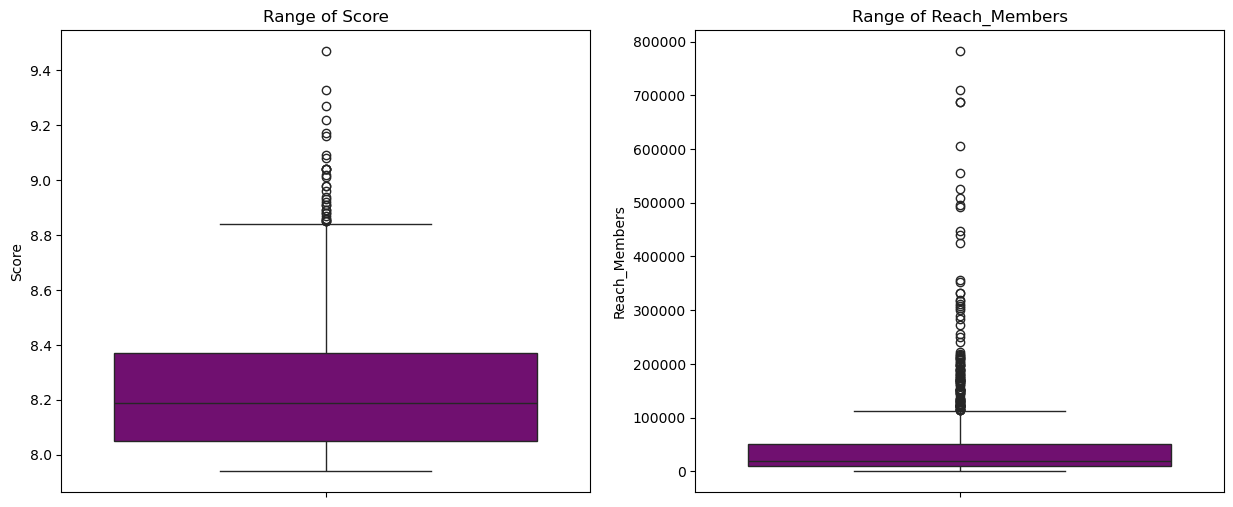

In [11]:
#[Manga Dataframe]
#Identifying the higher range SCORE : 9 to 9.4, REACH_MEMBERS : 450K+ 

cols_to_plot = ['Score', 'Reach_Members']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, col in enumerate(cols_to_plot):
    sns.boxplot(y=manga_df[col], ax=axes[i], color='purple')
    axes[i].set_title(f'Range of {col}')

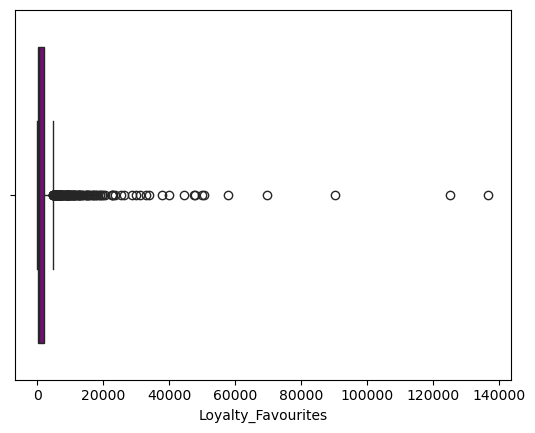

In [12]:
#[Manga Dataframe]
#Loyalty_Favourie Top 10 Range should be 40K + 
sns.boxplot(x = manga_df['Loyalty_Favourites'], color="purple");

***ANIME DATAFRAME***

In [62]:
#Anime DataFrame
#Collecting 1000 Anime Titles data that includes useful features of its IP success from Jikan API  

anime_data = []
target_count = 1000
page = 1

print("Starting Anime Data Collection...")

while len(anime_data) < target_count:
    url = f"https://api.jikan.moe/v4/top/anime?page={page}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json().get('data', [])
        
        for item in data:
            if len(anime_data) >= target_count:
                break
            
            # The dictionary must be indented inside the 'for item in data' loop
            row = {
                'Anime_ID': item.get('mal_id'),
                'Title': item.get('title'),
        
                # STORY DNA & ORIGIN
                'Originated_From': item.get('source'), 
                'Story_DNA': item.get('synopsis'),      
        
                # MARKET PERFORMANCE
                'Popularity_Rank': item.get('popularity'), 
                'Score': item.get('score'),
                'Reach_Members': item.get('members'),      
                'Loyalty_Favourites': item.get('favorites'), 
        
                # CATEGORIZATION
                'Main_Genre': ", ".join([g['name'] for g in item.get('genres', [])]) if item.get('genres') else 'N/A',
        
                # PRODUCTION DATA
                'Studios': ", ".join([s['name'] for s in item.get('studios', [])]) if item.get('studios') else 'N/A',
                'Producers': item.get('producers'), 
                'Licensors': item.get('licensors'),
        
                # LOGISTICS
                'Episodes': item.get('episodes'),  
                'Airing_Year': item.get('year'),
                'Rating': item.get('rating')            
            }
            anime_data.append(row)
        
        print(f"✅ Page {page} done. Total Collected: {len(anime_data)}")
        page += 1
        time.sleep(1) # mitigation for 429 errors
        
    elif response.status_code == 429:
        print("⏳ Rate limited! Waiting 30 seconds...")
        time.sleep(30)
    else:
        print(f"❌ Error {response.status_code}. Stopping.")
        break

anime_df = pd.DataFrame(anime_data)
# Saving this on csv 
anime_df.to_csv('top_anime_dataset.csv', index=False)
print("Data saved to 'top_anime_dataset.csv'!")

Starting Anime Data Collection...
✅ Page 1 done. Total Collected: 25
✅ Page 2 done. Total Collected: 50
✅ Page 3 done. Total Collected: 75
✅ Page 4 done. Total Collected: 100
✅ Page 5 done. Total Collected: 125
✅ Page 6 done. Total Collected: 150
✅ Page 7 done. Total Collected: 175
✅ Page 8 done. Total Collected: 200
✅ Page 9 done. Total Collected: 225
✅ Page 10 done. Total Collected: 250
✅ Page 11 done. Total Collected: 275
✅ Page 12 done. Total Collected: 300
✅ Page 13 done. Total Collected: 325
✅ Page 14 done. Total Collected: 350
✅ Page 15 done. Total Collected: 375
✅ Page 16 done. Total Collected: 400
✅ Page 17 done. Total Collected: 425
✅ Page 18 done. Total Collected: 450
✅ Page 19 done. Total Collected: 475
✅ Page 20 done. Total Collected: 500
✅ Page 21 done. Total Collected: 525
✅ Page 22 done. Total Collected: 550
✅ Page 23 done. Total Collected: 575
✅ Page 24 done. Total Collected: 600
✅ Page 25 done. Total Collected: 625
✅ Page 26 done. Total Collected: 650
✅ Page 27 done. 

In [63]:
#Checking how API data was converted into dataframe, checking the top 27 sorted by Loyalty_Favourites 
anime_df.sort_values(by='Loyalty_Favourites', ascending=False).head(27)

,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,Producers,Licensors,Episodes,Airing_Year,Rating
52,21,One Piece,Manga,Barely surviving in a barrel after passing thr...,17,8.73,2627169,247691,"Action, Adventure, Fantasy",Toei Animation,"[{'mal_id': 169, 'type': 'anime', 'name': 'Fuj...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",NaN,1999.0,PG-13 - Teens 13 or older
3,5114,Fullmetal Alchemist: Brotherhood,Manga,After a horrific alchemy experiment goes wrong...,3,9.10,3626424,239581,"Action, Adventure, Drama, Fantasy",Bones,"[{'mal_id': 17, 'type': 'anime', 'name': 'Anip...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",64.0,2009.0,R - 17+ (violence & profanity)
8,11061,Hunter x Hunter (2011),Manga,Hunters devote themselves to accomplishing haz...,8,9.03,3132401,226676,"Action, Adventure, Fantasy",Madhouse,"[{'mal_id': 29, 'type': 'anime', 'name': 'VAP'...","[{'mal_id': 119, 'type': 'anime', 'name': 'VIZ...",148.0,2011.0,PG-13 - Teens 13 or older
4,9253,Steins;Gate,Visual novel,Eccentric scientist Rintarou Okabe has a never...,14,9.07,2772703,200241,"Drama, Sci-Fi, Suspense",White Fox,"[{'mal_id': 61, 'type': 'anime', 'name': 'Fron...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",24.0,2011.0,PG-13 - Teens 13 or older
122,16498,Shingeki no Kyojin,Manga,"Centuries ago, mankind was slaughtered to near...",1,8.57,4292239,186098,"Action, Award Winning, Drama, Suspense",Wit Studio,"[{'mal_id': 10, 'type': 'anime', 'name': 'Prod...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",25.0,2013.0,R - 17+ (violence & profanity)
98,1535,Death Note,Manga,"Brutal murders, petty thefts, and senseless vi...",2,8.62,4232646,183895,"Supernatural, Suspense",Madhouse,"[{'mal_id': 29, 'type': 'anime', 'name': 'VAP'...","[{'mal_id': 119, 'type': 'anime', 'name': 'VIZ...",37.0,2006.0,R - 17+ (violence & profanity)
332,1735,Naruto: Shippuuden,Manga,It has been two and a half years since Naruto ...,15,8.29,2706689,119182,"Action, Adventure, Fantasy",Studio Pierrot,"[{'mal_id': 16, 'type': 'anime', 'name': 'TV T...","[{'mal_id': 119, 'type': 'anime', 'name': 'VIZ...",500.0,2007.0,PG-13 - Teens 13 or older
251,30,Shinseiki Evangelion,Original,Fifteen years after a cataclysmic event known ...,45,8.37,1994482,115802,"Avant Garde, Award Winning, Drama, Sci-Fi, Sus...","Gainax, Tatsunoko Production","[{'mal_id': 16, 'type': 'anime', 'name': 'TV T...","[{'mal_id': 97, 'type': 'anime', 'name': 'ADV ...",26.0,1995.0,PG-13 - Teens 13 or older
63,1575,Code Geass: Hangyaku no Lelouch,Original,"In the year 2010, the Holy Empire of Britannia...",22,8.71,2435669,115678,"Award Winning, Drama, Sci-Fi",Sunrise,"[{'mal_id': 23, 'type': 'anime', 'name': 'Band...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",25.0,2006.0,R - 17+ (violence & profanity)
152,40748,Jujutsu Kaisen,Manga,Idly indulging in baseless paranormal activiti...,13,8.52,2952261,94935,"Action, Award Winning, Supernatural",MAPPA,"[{'mal_id': 143, 'type': 'anime', 'name': 'Mai...","[{'mal_id': 119, 'type': 'anime', 'name': 'VIZ...",24.0,2020.0,R - 17+ (violence & profanity)


In [70]:
print (anime_df['Producers'].iloc[0])

[{'mal_id': 17, 'type': 'anime', 'name': 'Aniplex', 'url': 'https://myanimelist.net/anime/producer/17/Aniplex'}, {'mal_id': 53, 'type': 'anime', 'name': 'Dentsu', 'url': 'https://myanimelist.net/anime/producer/53/Dentsu'}, {'mal_id': 62, 'type': 'anime', 'name': 'Shogakukan-Shueisha Productions', 'url': 'https://myanimelist.net/anime/producer/62/Shogakukan-Shueisha_Productions'}, {'mal_id': 1003, 'type': 'anime', 'name': 'Nippon Television Network', 'url': 'https://myanimelist.net/anime/producer/1003/Nippon_Television_Network'}, {'mal_id': 1143, 'type': 'anime', 'name': 'TOHO animation', 'url': 'https://myanimelist.net/anime/producer/1143/TOHO_animation'}, {'mal_id': 1294, 'type': 'anime', 'name': 'Sound Team Don Juan', 'url': 'https://myanimelist.net/anime/producer/1294/Sound_Team_Don_Juan'}, {'mal_id': 1406, 'type': 'anime', 'name': 'Miracle Bus', 'url': 'https://myanimelist.net/anime/producer/1406/Miracle_Bus'}, {'mal_id': 1430, 'type': 'anime', 'name': 'Shogakukan', 'url': 'https:/

In [15]:
#checking data types of the anime dataframe 
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anime_ID            1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Originated_From     1000 non-null   object 
 3   Story_DNA           998 non-null    object 
 4   Popularity_Rank     1000 non-null   int64  
 5   Score               1000 non-null   float64
 6   Reach_Members       1000 non-null   int64  
 7   Loyalty_Favourites  1000 non-null   int64  
 8   Main_Genre          1000 non-null   object 
 9   Studios             1000 non-null   object 
 10  Episodes            990 non-null    float64
 11  Airing_Year         560 non-null    float64
 12  Rating              1000 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 101.7+ KB


In [64]:
#What are inside the column 'Originated_From'? 
anime_df['Originated_From'].unique()

array(['Manga', 'Visual novel', 'Light novel', 'Novel', 'Original',
       'Web manga', '4-koma manga', 'Web novel', 'Music', 'Game', 'Other',
       'Book', 'Mixed media', 'Picture book'], dtype=object)

In [65]:
#Checking what's inside 
url = "https://api.jikan.moe/v4/top/anime?page=1"
response = requests.get(url)

if response.status_code == 200:
    # first item in the 'data' list
    first_anime = response.json()['data'][0]
    print(first_anime.keys())
else:
    print(f"Error: {response.status_code}")

dict_keys(['mal_id', 'url', 'images', 'trailer', 'approved', 'titles', 'title', 'title_english', 'title_japanese', 'title_synonyms', 'type', 'source', 'episodes', 'status', 'airing', 'aired', 'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'synopsis', 'background', 'season', 'year', 'broadcast', 'producers', 'licensors', 'studios', 'genres', 'explicit_genres', 'themes', 'demographics'])


In [71]:
#Data Cleaning 
#1: Rating from object to numerical 
anime_df['Rating'] = pd.to_numeric(anime_df['Rating'], errors='coerce')

#2: Studios, Main_Genre, Originated_From 
cols_to_convert = ['Studios', 'Main_Genre', 'Originated_From']

for col in cols_to_convert:
    anime_df[col], mapping = pd.factorize(anime_df[col])

print(anime_df[cols_to_convert].head())

   Studios  Main_Genre  Originated_From
0        0           0                0
1        0           0                0
2        1           1                0
3        2           2                0
4        3           3                1


In [72]:
#converting Anime_ID to integer as I found out that one of the cells included texts 
anime_df['Anime_ID'] = pd.to_numeric(anime_df['Anime_ID'], errors='coerce')
anime_df = anime_df.dropna(subset=['Anime_ID'])
anime_df['Anime_ID'] = anime_df['Anime_ID'].astype(int)

In [73]:
#selected titles that are studio originated 
long_tail_studio = ['Evangelion', 'your name is', 'Cowboy Bebop', 'Violet Evergarden', 'suzume','ghost in shell', 'spiritied away', 'totoro', 'moving castle', 'kiki']
long_tail_manga = []
# 2. Join them with the '|' (OR) symbol
pattern = '|'.join(long_tail_studio) 

# 3. Search the DataFrame (case-insensitive)
# na=False prevents errors if you have empty rows
found_anime = anime_df[anime_df['Title'].str.contains(pattern, case=False, na=False)]
print(found_anime[['Anime_ID', 'Title']])

     Anime_ID                                              Title
30      37987                            Violet Evergarden Movie
47          1                                       Cowboy Bebop
70      33352                                  Violet Evergarden
118      3786                           Shin Evangelion Movie:||
129        32  Shinseiki Evangelion Movie: Air/Magokoro wo, K...
213     39741  Violet Evergarden Gaiden: Eien to Jidou Shuki ...
227     53672                   Violet Evergarden: Recollections
243         5                    Cowboy Bebop: Tengoku no Tobira
251        30                               Shinseiki Evangelion
271     37095  Violet Evergarden: Kitto "Ai" wo Shiru Hi ga K...
316      3784                             Evangelion Movie 2: Ha
368       523                                   Tonari no Totoro
371     50594                                 Suzume no Tojimari
722      2759                             Evangelion Movie 1: Jo
763     42166            

In [74]:
#[Anime DataFrame]
#The Long-Tails -  'Neon Genesis Evangelion', 'Cowboy Bebop', Metric-High "Favorites" ratio, even years after release.
#The Manga Boosters -	Demon Slayer, Jujutsu Kaisen, Massive "Members" count, clear link to Shueisha/Jump.
#The "Short-Tails - High-budget seasonal shows that were forgotten - High "Score" initially, but very low "Favorites" or "Popularity" growth

long_tail_astudio = [37987, 1, 33352, 3786, 32, 39741, 53672, 5, 30, 37095, 3784, 523, 50594, 2759, 42166] 

anime_df['Long_Tail_Astudio'] = anime_df['Anime_ID'].isin(long_tail_astudio).astype(int)

correlation = anime_df.corr(numeric_only=True)['Long_Tail_Astudio'].sort_values(ascending=True)
print(correlation)
corr_data = correlation.drop('Long_Tail_Astudio').to_frame()

Airing_Year          -0.078681
Popularity_Rank      -0.055775
Anime_ID             -0.051029
Studios              -0.047093
Main_Genre           -0.034163
Episodes             -0.027375
Originated_From       0.058132
Reach_Members         0.075114
Loyalty_Favourites    0.078060
Score                 0.088300
Long_Tail_Astudio     1.000000
Rating                     NaN
Name: Long_Tail_Astudio, dtype: float64


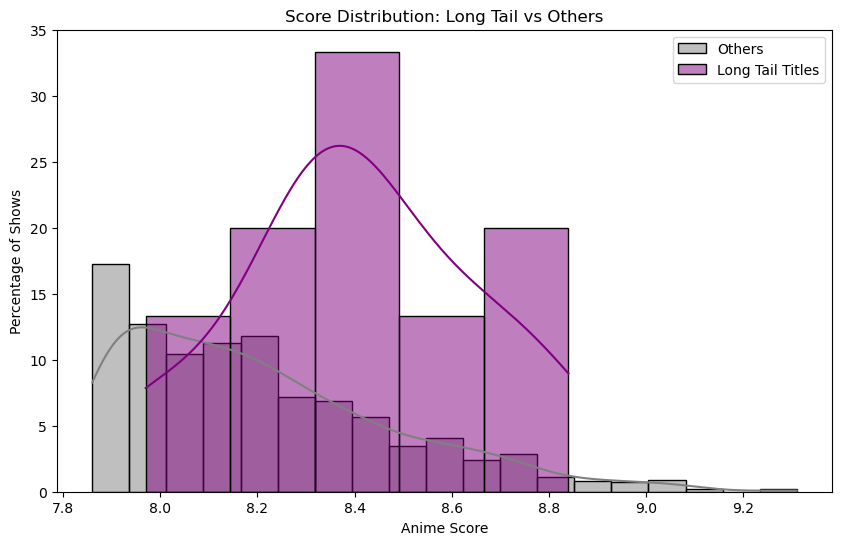

In [76]:
#Comparison of the Anime Originated Long Tail vs Others to see what is different in successful ones 
plt.figure(figsize=(10, 6))
sns.histplot(anime_df[anime_df['Long_Tail_Astudio'] == 0]['Score'], 
             color='gray', label='Others', kde=True, stat="percent")
sns.histplot(anime_df[anime_df['Long_Tail_Astudio'] == 1]['Score'], 
             color='purple', label='Long Tail Titles', kde=True, stat="percent")

plt.title('Score Distribution: Long Tail vs Others')
plt.xlabel('Anime Score')
plt.ylabel('Percentage of Shows')
plt.legend()
plt.show()

C:\Users\akoki\AppData\Local\Temp\ipykernel_16168\1478454896.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=abs_correlation.values, y=abs_correlation.index, palette='magma')


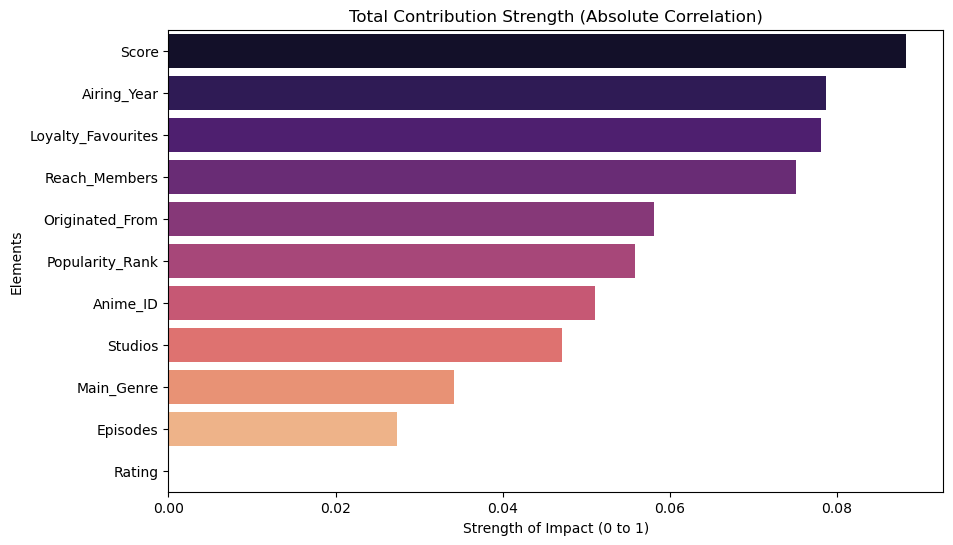

In [77]:
#[Anime DataFrame]
#Assessing what is correlated to (contributed to) Long Tail Anime Studio Originated Anime IPs 
abs_correlation = correlation.drop('Long_Tail_Astudio').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=abs_correlation.values, y=abs_correlation.index, palette='magma')

plt.title("Total Contribution Strength (Absolute Correlation)")
plt.xlabel("Strength of Impact (0 to 1)")
plt.ylabel("Elements")
plt.show()

Loyalty_Favourites    1.000000
Reach_Members         0.816752
Score                 0.364328
Episodes              0.135869
Long_Tail_Astudio     0.078060
Originated_From      -0.085307
Airing_Year          -0.101883
Main_Genre           -0.109829
Anime_ID             -0.160037
Studios              -0.182798
Popularity_Rank      -0.317219
Rating                     NaN
Name: Loyalty_Favourites, dtype: float64


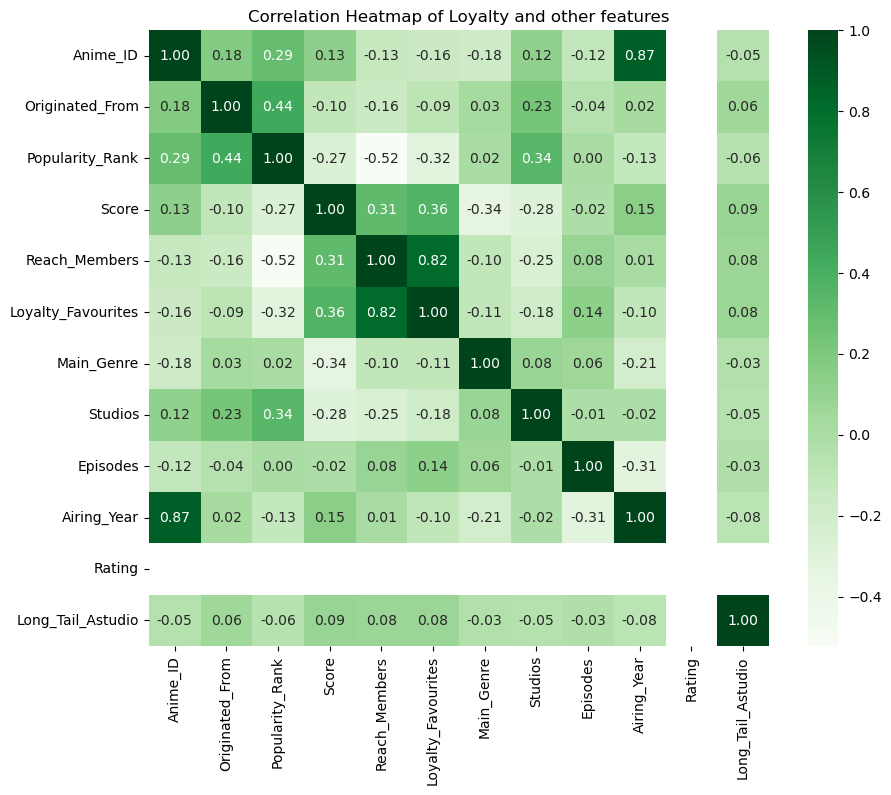

In [78]:
correlation_matrix = anime_df.corr(numeric_only=True)
print(correlation_matrix['Loyalty_Favourites'].sort_values(ascending=False))
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.title("Correlation Heatmap of Loyalty and other features")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

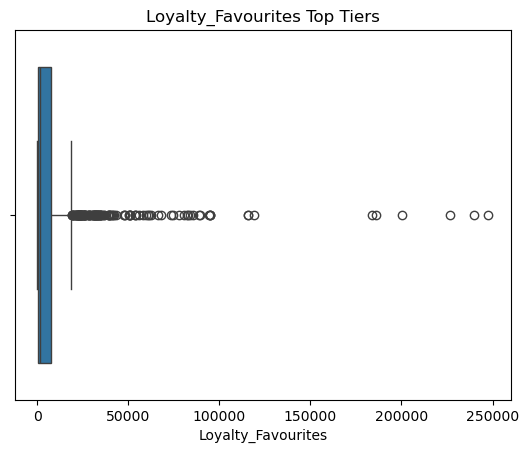

In [79]:
#Using Boxplotting to see in Anime DataFrame where the top tiers belong, seems to be above 61K+ 
sns.boxplot(x=anime_df['Loyalty_Favourites'])
plt.title('Loyalty_Favourites Top Tiers')
plt.show

In [80]:
# Based on the above Boxplot, creating a new column with 'is_hit' with threhold of 61K+
anime_df['is_hit'] = np.where(anime_df['Loyalty_Favourites'] >= 61000, 1, 0)
print(anime_df['is_hit'].value_counts())

is_hit
0    973
1     27
Name: count, dtype: int64


In [95]:
#Surpervised Machine Learning Trial 
#1 : Separating Features from Target Column in Surpervised Machine Learning 
target = anime_df['is_hit']

features = anime_df.drop(columns=["Episodes", "Airing_Year", "Rating", "Anime_ID", "Loyalty_Favourites", "is_hit", "Reach_Members", "Title", "Story_DNA", "Long_Tail_Astudio", "Producers", "Licensors"
], errors='ignore')

scaler = StandardScaler()
feature_scaled = scaler.fit_transform(features)
feature_scaled_df = pd.DataFrame(feature_scaled, columns=features.columns)

In [96]:
#Surpervised Machine Learning Trial 
#Spliting Test & Train 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [97]:
#Random Forest Classifier to predict the Hit Makers 
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)

# performance evaluation
print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

--- Random Forest Results ---
Accuracy: 99.00%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       194
           1       1.00      0.67      0.80         6

    accuracy                           0.99       200
   macro avg       0.99      0.83      0.90       200
weighted avg       0.99      0.99      0.99       200



In [98]:
# 2 False Negative, 4 True Positives, we have regular ones more, so 98% is very normal as we have about 2% hit ratio 
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Confusion Matrix ---
[[194   0]
 [  2   4]]


In [99]:
# Compensating for the lack of numbers in hit 
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
# Getting the Prediction again
y_pred = clf_model.predict(X_test)

# Only Precision Rate improved but NOT recall 
print(classification_report(y_test, y_pred))

#Confusion Matrix has no change,or worse 
cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       194
           1       1.00      0.67      0.80         6

    accuracy                           0.99       200
   macro avg       0.99      0.83      0.90       200
weighted avg       0.99      0.99      0.99       200



array([[194,   0],
       [  2,   4]])

In [101]:
#SMOTE to balance the imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training size: {X_train.shape[0]}")
print(f"New training size after SMOTE: {X_train_res.shape[0]}")

forest_smote_clf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
forest_smote_clf.fit(X_train_res, y_train_res)

pred_smote = forest_smote_clf.predict(X_test)

print("--- Results with SMOTE ---")
print(f"Accuracy Score: {accuracy_score(y_test, pred_smote):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_smote))


Original training size: 800
New training size after SMOTE: 1558
--- Results with SMOTE ---
Accuracy Score: 0.9700

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       194
           1       0.50      0.83      0.62         6

    accuracy                           0.97       200
   macro avg       0.75      0.90      0.80       200
weighted avg       0.98      0.97      0.97       200



In [102]:
#Confusion Matrix again, 1 false positive and 5 true positives 
cm = confusion_matrix(y_test, pred_smote)
cm

array([[189,   5],
       [  1,   5]])

SMOTE improved the Recall Macro Average from 83% to 90%, 67% to 83%, but precision reduced to 50% 
***Conclusion : It is not the good balancing technique for this particular case, so more features to be added***

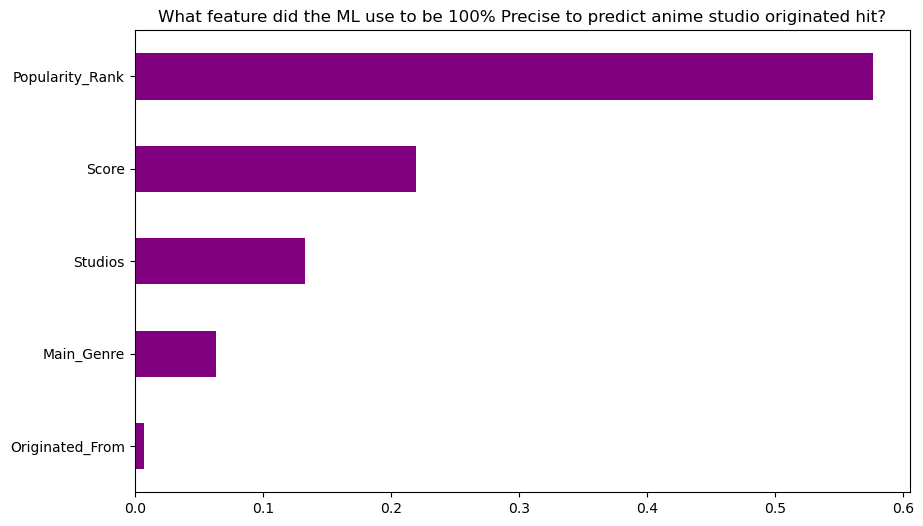

In [104]:
#Which feature contribute the best to predict hit or not 
importances = pd.Series(clf_model.feature_importances_, index=features.columns)
importances.sort_values().plot(kind='barh', color='purple', figsize=(10, 6))
plt.title("What feature did the ML use to be 100% Precise to predict anime studio originated hit?")
plt.show()

***DataFrame for Manga/Anime IP's Game Expansion***
RAWG Video Games Database API : 

The largest open video games database that includes more than 350,000 games for 50 platforms including mobiles.
Using meta data such as the following to identify IPs that made it to Game world. 
tags, genres, developers, publishers, individual creators, official websites, release dates, Metacritic ratings

In [35]:
#Connecting to RAWG API with token 
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("RAWG_API_KEY")

In [36]:
#[Games DataFrame]
#looking to see whats inside of RAWG games database API  
test_response = requests.get(f"https://api.rawg.io/api/games?key={API_KEY}&page_size=1")
print(test_response.json()['results'][0].keys()) 

dict_keys(['id', 'slug', 'name', 'released', 'tba', 'background_image', 'rating', 'rating_top', 'ratings', 'ratings_count', 'reviews_text_count', 'added', 'added_by_status', 'metacritic', 'playtime', 'suggestions_count', 'updated', 'user_game', 'reviews_count', 'saturated_color', 'dominant_color', 'platforms', 'parent_platforms', 'genres', 'stores', 'clip', 'tags', 'esrb_rating', 'short_screenshots'])


In [37]:
#Collecting 
import os
import requests
import pandas as pd
import time



game_data = []
target_count = 1000 
page = 1

print("🚀 Starting RAWG Game Data Collection...")

while len(game_data) < target_count:
    # RAWG uses &key= and &page=
    url = f"https://api.rawg.io/api/games?key={API_KEY}&page={page}&page_size=40"
    
    response = requests.get(url)

    if response.status_code == 200:
        # RAWG puts the list inside the 'results' key
        data = response.json().get('results', [])
        
        if not data:
            print("No more data available.")
            break

        for item in data:
            if len(game_data) >= target_count:
                break
            
            row = {
                'Game_ID': item.get('id'),
                'Title': item.get('name'),
                'Release_Date': item.get('released'),
                'Rating_Score': item.get('rating'),  
                'Metacritic': item.get('metacritic'),
                'Playtime_Avg': item.get('playtime'),
                'Genres': ", ".join([g['name'] for g in item.get('genres', [])]),
                'Platforms': ", ".join([p['platform']['name'] for p in item.get('platforms', [])]),
                'Ratings_Count': item.get('ratings_count'),
                'Suggestions_Count': item.get('suggestions_count'),
                'Updated_At': item.get('updated')
            }
            game_data.append(row)
        
        print(f"✅ Page {page} processed. Total: {len(game_data)}")
        page += 1
   
        time.sleep(1) 
        
    elif response.status_code == 429:
        print("⏳ Rate limited! Waiting...")
        time.sleep(10)
    else:
        print(f"❌ Error {response.status_code}. Stopping.")
        breakzzz

# 2. Convert to DataFrame
games_df = pd.DataFrame(game_data)
print("📦 Collection Complete!")

🚀 Starting RAWG Game Data Collection...
✅ Page 1 processed. Total: 40
✅ Page 2 processed. Total: 80
✅ Page 3 processed. Total: 120
✅ Page 4 processed. Total: 160
✅ Page 5 processed. Total: 200
✅ Page 6 processed. Total: 240
✅ Page 7 processed. Total: 280
✅ Page 8 processed. Total: 320
✅ Page 9 processed. Total: 360
✅ Page 10 processed. Total: 400
✅ Page 11 processed. Total: 440
✅ Page 12 processed. Total: 480
✅ Page 13 processed. Total: 520
✅ Page 14 processed. Total: 560
✅ Page 15 processed. Total: 600
✅ Page 16 processed. Total: 640
✅ Page 17 processed. Total: 680
✅ Page 18 processed. Total: 720
✅ Page 19 processed. Total: 760
✅ Page 20 processed. Total: 800
✅ Page 21 processed. Total: 840
✅ Page 22 processed. Total: 880
✅ Page 23 processed. Total: 920
✅ Page 24 processed. Total: 960
✅ Page 25 processed. Total: 1000
📦 Collection Complete!


In [56]:
#[Games Dataframe]
#RAWG API 
games_df.head(5)
games_df.to_csv('RAWG_dataset.csv', index=False)
print("Data saved")
games_df

Data saved


,Game_ID,Title,Release_Date,Rating_Score,Metacritic,Playtime_Avg,Genres,Platforms,Ratings_Count,Suggestions_Count,Updated_At
0,3498,Grand Theft Auto V,2013-09-17,4.47,92.0,74,Action,"PlayStation 5, Xbox Series S/X, PlayStation 3,...",7307,446,2026-01-22T06:17:45
1,3328,The Witcher 3: Wild Hunt,2015-05-18,4.64,92.0,43,"Action, RPG","PlayStation 5, Xbox Series S/X, macOS, PlaySta...",7117,688,2026-01-19T21:37:58
2,4200,Portal 2,2011-04-18,4.58,95.0,11,"Shooter, Puzzle","PlayStation 3, PC, Xbox 360, Linux, macOS, Xbo...",6042,567,2026-01-22T06:44:30
3,4291,Counter-Strike: Global Offensive,2012-08-21,3.57,81.0,64,Shooter,"PC, Linux, Xbox 360, PlayStation 3",3613,607,2026-01-15T12:59:32
4,5286,Tomb Raider (2013),2013-03-05,4.06,86.0,10,Action,"PlayStation 3, Xbox 360, macOS, PC",4066,660,2026-01-19T05:58:05
...,...,...,...,...,...,...,...,...,...,...,...
995,10606,Mirage: Arcane Warfare,2017-05-23,2.17,74.0,3,"Action, Indie",PC,177,631,2025-11-04T20:30:23
996,5426,Crash Bandicoot 3: Warped,1998-10-31,4.34,91.0,5,"Action, Platformer",PlayStation,650,396,2026-01-05T19:10:12
997,45109,Maneater,2020-05-22,3.43,68.0,4,"Action, Adventure, RPG, Indie","PlayStation 5, PlayStation 4, PC, Xbox One, Ni...",259,534,2026-01-03T10:30:26
998,12322,Emily is Away,2015-11-20,3.58,NaN,1,"Adventure, Simulation, Casual, Indie","Linux, PC, macOS",436,76,2026-01-04T01:33:58


In [39]:
#Loading Twitch Game API IGDB 

load_dotenv()

client_id = os.getenv("client_id")
client_secret = os.getenv("client_secret")

#askig for authorisation 
auth_url = "https://id.twitch.tv/oauth2/token"
auth_params = {
    'client_id': client_id,
    'client_secret': client_secret,
    'grant_type': 'client_credentials'
}

response = requests.post(auth_url, params=auth_params)

if response.status_code == 200:
    access_token = response.json().get('access_token')
    print("✅ Handshake Successful!")
    print(f"Your temporary Access Token starts with: {access_token[:8]}...")
else:
    print(f"❌ Handshake Failed: {response.status_code}")
    print(response.json())

✅ Handshake Successful!
Your temporary Access Token starts with: fq9mdqgz...


In [40]:
#{Game DataFrame]
# The header must contain BOTH the Client-ID and the Authorization token
headers = {
    'Client-ID': client_id,
    'Authorization': f'Bearer {access_token}'
}

# Example: Get the top 5 games with their release dates
# IGDB uses a special query language in the "data" field
query = "fields name, first_release_date; limit 5;"
igdb_response = requests.post("https://api.igdb.com/v4/games", headers=headers, data=query)

print(igdb_response.json())

[{'id': 350392, 'name': 'Rival Species'}, {'id': 30492, 'first_release_date': 1483660800, 'name': 'Hearts of Chaos'}, {'id': 339266, 'first_release_date': 1692057600, 'name': 'Power Guy World'}, {'id': 371776, 'name': 'Born for the Light: Wavelength Radiant Collapse'}, {'id': 376989, 'first_release_date': 1193702400, 'name': 'Dune Buggy'}]


In [41]:
# Reading Metadatas to see which parameters to read for the dataframe, Twitch version is more extensive 
metadata_url = "https://api.igdb.com/v4/games/meta"
metadata_response = requests.get(metadata_url, headers=headers)
print(metadata_response.json())

['age_ratings', 'aggregated_rating', 'aggregated_rating_count', 'alternative_names', 'artworks', 'bundles', 'category', 'collection', 'cover', 'created_at', 'dlcs', 'expansions', 'external_games', 'first_release_date', 'follows', 'franchise', 'franchises', 'game_engines', 'game_modes', 'genres', 'hypes', 'involved_companies', 'keywords', 'multiplayer_modes', 'name', 'parent_game', 'platforms', 'player_perspectives', 'rating', 'rating_count', 'release_dates', 'screenshots', 'similar_games', 'slug', 'standalone_expansions', 'status', 'storyline', 'summary', 'tags', 'themes', 'total_rating', 'total_rating_count', 'updated_at', 'url', 'version_parent', 'version_title', 'videos', 'websites', 'checksum', 'remakes', 'remasters', 'expanded_games', 'ports', 'forks', 'language_supports', 'game_localizations', 'collections', 'game_status', 'game_type']


In [44]:
#Loading Twitch IGDB API into dataframe 
# Configuration
target_count = 1000
limit = 50  
offset = 0
twitch_data = []

# Ensure your headers are defined before this block
# headers = {'Client-ID': 'your_id', 'Authorization': 'Bearer your_token'}

print("🚀 Starting Clean & Broad IGDB Data Collection (Excluding Erotica)...")

while len(twitch_data) < target_count:
    # Logic: 
    # 1. total_rating_count != n (ensures the game has feedback/popularity)
    # 2. genres != (35) (EXCLUDES Erotica)
    # 3. keywords = (24) OR keywords = (112) etc. (Optional: add keywords like 'cel shaded' if you want that look)
    
    query = f"""
    fields name, first_release_date, category, status,
           game_engines.name, game_modes.name, genres.name, platforms.name,
           involved_companies.company.name, involved_companies.developer, involved_companies.publisher,
           keywords.name, storyline, summary, themes.name,
           total_rating, total_rating_count, follows, hypes, player_perspectives.name;
    
    where total_rating_count != n & genres != (35);
    sort total_rating_count desc;
    limit {limit};
    offset {offset};
    """
    
    response = requests.post("https://api.igdb.com/v4/games", headers=headers, data=query)

    if response.status_code == 200:
        data = response.json()
        
        if not data:
            print("No more data found.")
            break

        for item in data:
            row = {
                'Title': item.get('name'),
                'Release_Date': item.get('first_release_date'),
                'Genres': ", ".join([g['name'] for g in item.get('genres', [])]),
                'Themes': ", ".join([t['name'] for t in item.get('themes', [])]),
                'Developer': ", ".join([c['company']['name'] for c in item.get('involved_companies', []) if c.get('developer')]),
                'Publisher': ", ".join([c['company']['name'] for c in item.get('involved_companies', []) if c.get('publisher')]),
                'Total_Rating': item.get('total_rating'),
                'Rating_Count': item.get('total_rating_count'),
                'Summary': item.get('summary')
            }
            twitch_data.append(row)
        
        print(f"Progress: {len(twitch_data)}/{target_count} titles (Offset: {offset})")
        offset += limit
        time.sleep(0.35) # Safe rate limit
        
    elif response.status_code == 429:
        print("Rate limited! Waiting 15s...")
        time.sleep(15)
    else:
        print(f"Error {response.status_code}: {response.text}")
        break

twitch_df = pd.DataFrame(twitch_data)
print(f"Collection Complete! Final Shape: {twitch_df.shape}")

🚀 Starting Clean & Broad IGDB Data Collection (Excluding Erotica)...
✅ Progress: 50/1000 titles (Offset: 0)
✅ Progress: 100/1000 titles (Offset: 50)
✅ Progress: 150/1000 titles (Offset: 100)
✅ Progress: 200/1000 titles (Offset: 150)
✅ Progress: 250/1000 titles (Offset: 200)
✅ Progress: 300/1000 titles (Offset: 250)
✅ Progress: 350/1000 titles (Offset: 300)
✅ Progress: 400/1000 titles (Offset: 350)
✅ Progress: 450/1000 titles (Offset: 400)
✅ Progress: 500/1000 titles (Offset: 450)
✅ Progress: 550/1000 titles (Offset: 500)
✅ Progress: 600/1000 titles (Offset: 550)
✅ Progress: 650/1000 titles (Offset: 600)
✅ Progress: 700/1000 titles (Offset: 650)
✅ Progress: 750/1000 titles (Offset: 700)
✅ Progress: 800/1000 titles (Offset: 750)
✅ Progress: 850/1000 titles (Offset: 800)
✅ Progress: 900/1000 titles (Offset: 850)
✅ Progress: 950/1000 titles (Offset: 900)
✅ Progress: 1000/1000 titles (Offset: 950)
📦 Collection Complete! Final Shape: (1000, 9)


In [388]:
famous_ips = 'one piece|naruto|bleach|gundam|demon slayer|jujutsukaisen|Evangelion|Cowboy Bebop|Violet Evergarden|Attack on Titan|My Hero Academia|Bleach|JoJo|That Time I Got Reincarnated as a Slim|Re:Zero|Fate/Grandorder|One Punch Man|Fullmetal Alchemist|Death Note|HunterxHunter|Steins;Gate|No Game No Life|Code Geass|Mob Psycho 100|Your lie in April|Angel Beats!|Haikyuu!!|Promised Neverland|konosuba|Parasyte'
tw_df = twitch_df[
    (twitch_df['Summary'].str.contains(famous_ips, case=False, na=False)) & 
    (~twitch_df['Themes'].str.contains('erotic', case=False, na=False))
]

# 3. Sort
top_clean_games = tw_df.sort_values(by='Total_Rating', ascending=False)
tw_df
tw_df.to_csv('twitch_filtered_dataset.csv', index=False)
print("Data saved")
tw_df

Data saved


,Title,Release_Date,Genres,Themes,Developer,Publisher,Total_Rating,Rating_Count,Summary
188,Halo 3,1190678400,Shooter,"Action, Science fiction, Sandbox, Warfare",Bungie,Microsoft Game Studios,88.087008,800,Halo 3 is a shooter game where players primari...
611,Steins;Gate,1255564800,"Adventure, Visual Novel","Science fiction, Survival, Historical, Mystery","MAGES., NITRO PLUS, 5pb.","PQube, JAST USA, MAGES., Kadokawa Shoten, 5pb.",86.645500,286,Steins;Gate is a Japanese visual novel develop...
961,Naruto Shippuden: Ultimate Ninja Storm 4,1454544000,"Fighting, Adventure",Action,CyberConnect2,Bandai Namco Entertainment,76.324208,193,Experience the exhilarating full-adventure Nar...


In [387]:
gp_df = pd.read_csv("games_info.csv")

In [385]:
#Trying to assess if there is any tie up that happened between the famous IP & global gamees 
#famous_ips = 'one piece|naruto|dragon ball|bleach|gundam|demon slayer|pokemon|digimon|yu-gi-oh|jujutsukaisen|Evangelion|Cowboy Bebop|Violet Evergarden|Attack on Titan'
clean_gpdf = gp_df[
    (gp_df['description'].str.contains(famous_ips, case=False, na=False)) 
]

# 3. Sort
top_clean_games = clean_gpdf.sort_values(by='downloads', ascending=False)
clean_gpdf
clean_gpdf.to_csv('Google_Play_filtered_dataset.csv', index=False)
print("Data saved")
clean_gpdf

Data saved


,game_id,game_name,description,score,ratings_count,downloads,content_rating,section,categories
321,322,Blood Strike - FPS for all,Blood Strike x Attack on Titan Collaboration S...,4.3,760000,50000000,Teen,Stylized games,"Action, Shooter, Tactical shooter, Casual, Mul..."


In [386]:
#Raw Games filtered by famous IPs 
rawg_df = games_df[
    (games_df['Title'].str.contains(famous_ips, case=False, na=False))]

# Sort
top_clean_raw_games = rawg_df.sort_values(by='Suggestions_Count', ascending=False)
rawg_df.to_csv('rawg_filtered_dataset.csv', index=False)
print("Data saved")
rawg_df

Data saved


,Game_ID,Title,Release_Date,Rating_Score,Metacritic,Playtime_Avg,Genres,Platforms,Ratings_Count,Suggestions_Count,Updated_At
930,2828,NARUTO SHIPPUDEN: Ultimate Ninja STORM 4,2016-02-04,4.02,80.0,8,"Action, Fighting","PC, Xbox One, PlayStation 4",499,524,2025-12-14T19:15:38


In [ ]:
#Twitch Games Filtered by famous IPs 


In [190]:
#Merch Global Traction Database 
#Web Scraping from Crunchroll Merch Website 

import re 

def get_merch_count(anime_name):
    search_url = f"https://store.crunchyroll.com/search?q={anime_name.replace(' ', '+')}&sz=1"
    
    # Adding a more realistic User-Agent helps prevent blocks
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
    }
    
    try:
        response = requests.get(search_url, headers=headers, timeout=10)
        
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            # Crunchyroll often uses 'result-count' or 'results-count' class
            results = soup.find('span', class_='results-count') or soup.find('div', class_='result-count')
            
            if results:
                # Use Regex to find the number in "158 results"
                count_str = results.get_text().strip()
                count_num = re.findall(r'\d+', count_str) # Returns a list of numbers
                return int(count_num[0]) if count_num else 0
            return 0
            
        elif response.status_code == 429:
            print("Rate limited! Slowing down...")
            return None # Signal that we need to wait
            
    except Exception as e:
        print(f"Error for {anime_name}: {e}")
        return 0
    return 0

# Test it
#print(f"Frieren Merch Count (Clean): {get_merch_count('Frieren')}")
print(f"ds Merch Count (Clean): {get_merch_count('Dorohedoro')}")

ds Merch Count (Clean): 32


In [204]:
#Saved the Crunchroll Webscraping results on CSV 
merch_url = 'https://docs.google.com/spreadsheets/d/19WJqcmvaXPxALjTasfpE2E6YrYCDq5lBmA19T5ZWAf8/export?format=csv&gid=1294910894'
crmerch_df  = pd.read_csv(merch_url)
crmerch_df

,Anime_ID,Title,Merch_quantity
0,16498,Shingeki no Kyojin,163
1,1535,Death Note,36
2,5114,Fullmetal Alchemist: Brotherhood,51
3,30276,One Punch Man,47
4,38000,Kimetsu no Yaiba***,208
...,...,...,...
225,39565,Boku no Hero Academia the Movie 2: Heroes:Rising,0
226,48569,86 Part 2,0
227,42923,SK∞,4
228,48895,Overlord IV,0


In [315]:
#[DataFrame]
#clean_gpdf & tw_df : filtered twitch & rawg_df : filtered raw game data, steam 
#crmerch_df : Crunchroll Top Popularity Scorer 115 & anime_df  

merch_anime_df = pd.merge(anime_df, crmerch_df, on='Anime_ID')
top_merch = merch_anime_df.sort_values(by=['Merch_quantity'], ascending=False).head(3)
top_merch
# Saving this on csv 
merch_anime_df.to_csv('top_merch_dataset.csv', index=False)
print("Data saved to 'top_merch_dataset.csv'!")
merch_anime_df.head(1)

Data saved to 'top_merch_dataset.csv'!


,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,Producers,Licensors,Episodes,Airing_Year,Rating,Long_Tail_Astudio,is_hit,merge_key,Title,Merch_quantity
0,52991,Sousou no Frieren,0,During their decade-long quest to defeat the D...,114,9.28,1314756,82922,0,0,"[{'mal_id': 17, 'type': 'anime', 'name': 'Anip...","[{'mal_id': 1468, 'type': 'anime', 'name': 'Cr...",28.0,2023.0,NaN,0,1,sousounofrieren,Sousou no Frieren,0


In [343]:
#Merging Anime Dataframe with Manga Dataframe for per Studio Analysis 
studio_df = pd.read_csv('top_anime_dataset.csv')

#Cleaning lowercase, strip whitespace
manga_df['Title_Clean'] = manga_df['Title'].str.lower().str.strip()
studio_df['Title_Clean'] = studio_df['Title'].str.lower().str.strip()

#Merging based on cleaned titles 
manga_genre_df = pd.merge(
    manga_df, 
    studio_df[['Title_Clean', 'Studios']], 
    on='Title_Clean', 
    how='left'
)

#Dropping the cleaned column for better analysis later 
manga_genre_df.drop(columns=['Title_Clean'], inplace=True)

In [344]:
manga_genre_df.head(1)

,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Genres,Languages,Language_count,Award_Types,Award_count,Streaming,Streaming_count,Match,Matched_Anime_Title,merge_key,Studios
0,2,Berserk,9.47,782201,136664,"Guts, a former mercenary now known as the Blac...",Berserk won the Excellence Award at the sixth ...,Young Animal,"Action, Adventure, Award Winning, Drama, Fanta...","English, Thai, German",3,Award,1,None,0,105.0,Kenpuu Denki Berserk,berserk,NaN


In [352]:
#Created new [Manga Studio Dataframe] to check which Studio bring success to what kind of manga in which country 
import re

def create_key(text):
    if not isinstance(text, str): return ""
    # lowercasing, removing "Season", "Movie", "Final", remove alpha numeric 
    text = text.lower()
    text = re.sub(r'season \d+|final season|the movie|part \d+', '', text)
    text = re.sub(r'[^a-z0-9]', '', text) 
    return text.strip()

manga_genre_df['merge_key'] = manga_genre_df['Title'].apply(create_key)
studio_df['merge_key'] = studio_df['Title'].apply(create_key)

anime_subset = studio_df[['merge_key', 'Studios', 'Anime_ID']].drop_duplicates('merge_key')

manga_with_studio = pd.merge(manga_genre_df, anime_subset, on='merge_key', how='left')

manga_studio_df = manga_with_studio.dropna()
manga_studio_df.head(3)

,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Genres,Languages,...,Award_Types,Award_count,Streaming,Streaming_count,Match,Matched_Anime_Title,merge_key,Studios_x,Studios_y,Anime_ID
3,13,One Piece,9.22,686782,124999,"Gol D. Roger, a man referred to as the King of...",One Piece is the highest-selling manga series ...,Shounen Jump (Weekly),"Action, Adventure, Fantasy","English, Korean, Malay, Indonesian, Chinese, T...",...,"Award, finalist",2,"netflix, viz, manga plus",3,9.0,One Piece Fan Letter,onepiece,Toei Animation,Toei Animation,21.0
5,1,Monster,9.16,283848,23441,"Kenzou Tenma, a renowned Japanese neurosurgeon...",Monster won the Grand Prize at the third Tezuk...,Big Comic Original,"Award Winning, Drama, Mystery","English, Portuguese, Polish",...,Award,1,viz,1,24.0,Monster,monster,Madhouse,Madhouse,19.0
6,642,Vinland Saga,9.09,352461,37704,"Thorfinn, son of one of the Vikings' greatest ...",Vinland Saga won the Grand Prize in the Manga ...,Afternoon,"Action, Adventure, Award Winning, Drama","English, French, Spanish, Portuguese, Polish",...,Award,1,None,0,33.0,Vinland Saga Season 2,vinlandsaga,Wit Studio,MAPPA,49387.0


In [354]:
# 1. Split and Explode the Genres (Keep the NaNs in Studios for now)
manga_studio_df['Genres_List'] = manga_studio_df['Genres'].str.split(', ')
manga_expanded = manga_studio_df.explode('Genres_List')
manga_expanded['Genres_List'] = manga_expanded['Genres_List'].str.strip()

# 2. Filter out the inappropriate genres
exclude_list = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love', 'None', '']
manga_filtered = manga_expanded[~manga_expanded['Genres_List'].isin(exclude_list)]

# 3. Run Crosstab
# Crosstab automatically ignores rows where 'Studios' or 'Genres_List' is NaN
studio_genre_ct = pd.crosstab(
    manga_filtered['Studios_y'], 
    manga_filtered['Genres_List']
)

# 4. Calculate Ratio
# This will now only represent the 227 titles that actually matched
studio_genre_pct = studio_genre_ct.div(studio_genre_ct.sum(axis=0), axis=1)

print(f"Analysis based on {manga_filtered['Studios_y'].notna().sum()} genre-studio data points.")
print(studio_genre_pct.head())

Analysis based on 584 genre-studio data points.
Genres_List     Action  Adventure  Award Winning    Comedy     Drama  \
Studios_y                                                              
8bit          0.000000   0.000000       0.030303  0.000000  0.000000   
A-1 Pictures  0.043478   0.000000       0.075758  0.075758  0.063158   
A.C.G.T.      0.000000   0.023256       0.000000  0.000000  0.010526   
Ajia-do       0.000000   0.000000       0.000000  0.000000  0.000000   
Artland       0.014493   0.000000       0.015152  0.015152  0.000000   

Genres_List    Fantasy  Gourmet  Horror   Mystery   Romance    Sci-Fi  \
Studios_y                                                               
8bit          0.032787      0.0     0.0  0.000000  0.000000  0.000000   
A-1 Pictures  0.032787      0.0     0.0  0.074074  0.071429  0.157895   
A.C.G.T.      0.016393      0.0     0.0  0.000000  0.000000  0.000000   
Ajia-do       0.016393      0.0     0.0  0.000000  0.017857  0.000000   
Artland  

C:\Users\akoki\AppData\Local\Temp\ipykernel_16168\2438776174.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manga_studio_df['Genres_List'] = manga_studio_df['Genres'].str.split(', ')


<Axes: ylabel='Studios_y'>

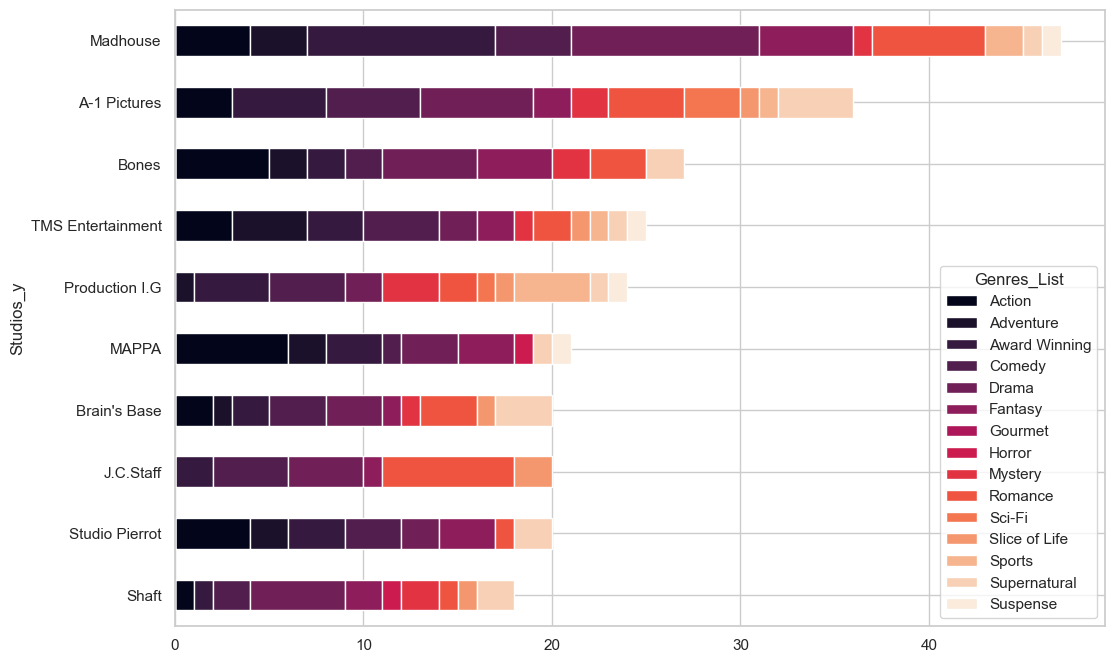

In [355]:
#Top studio and break down of the genres 
top_studios_list = studio_genre_ct.sum(axis=1).nlargest(10).index

#Top to bottom 
plot_data = studio_genre_ct.loc[top_studios_list][::-1]

plot_data.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='rocket')

In [360]:
# Language & Genre affinity map 
lang_genre_df = manga_studio_df[['Languages', 'Genres']].copy().dropna()
lang_genre_df['Genres'] = lang_genre_df['Genres'].str.split(',')
lang_genre_df = lang_genre_df.explode('Genres')
lang_genre_df['Genres'] = lang_genre_df['Genres'].str.strip()

exclude_list = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love']
lang_genre_df = lang_genre_df[~lang_genre_df['Genres'].isin(exclude_list)]

lang_genre_ct = pd.crosstab(lang_genre_df['Languages'], lang_genre_df['Genres'])

# ratio of the studio genre cross tabl 
lang_genre_pct = lang_genre_ct.div(lang_genre_ct.sum(axis=0), axis=1)

#print(lang_genre_pct.head())

In [459]:
merch_anime_df.head(30)

,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,...,Episodes,Airing_Year,Rating,Long_Tail_Astudio,is_hit,merge_key,Title,Merch_quantity,loyalty_ratio,globalisation
0,52991,Sousou no Frieren,0,During their decade-long quest to defeat the D...,114,9.28,1314756,82922,0,0,...,28.0,2023.0,NaN,0,1,sousounofrieren,Sousou no Frieren,0,0.063070,0.662303
1,5114,Fullmetal Alchemist: Brotherhood,0,After a horrific alchemy experiment goes wrong...,3,9.10,3626424,239581,2,2,...,64.0,2009.0,NaN,0,1,fullmetalalchemistbrotherhood,Fullmetal Alchemist: Brotherhood,51,0.066065,0.881523
2,9253,Steins;Gate,1,Eccentric scientist Rintarou Okabe has a never...,14,9.07,2772703,200241,3,3,...,24.0,2011.0,NaN,0,1,steinsgate,Steins;Gate,2,0.072219,0.768615
3,38524,Shingeki no Kyojin Season 3 Part 2,0,Seeking to restore humanity's diminishing hope...,20,9.05,2542707,62512,4,4,...,10.0,2019.0,NaN,0,1,shingekinokyojin,Shingeki no Kyojin Season 3 Part 2*,0,0.024585,0.245888
4,28977,Gintama°,0,"Gintoki, Shinpachi, and Kagura return as the f...",347,9.05,683530,17404,5,5,...,51.0,2015.0,NaN,0,0,gintama,Gintama°,0,0.025462,0.255379
5,11061,Hunter x Hunter (2011),0,Hunters devote themselves to accomplishing haz...,8,9.03,3132401,226676,7,0,...,148.0,2011.0,NaN,0,1,hunterxhunter2011,Hunter x Hunter (2011),101,0.072365,1.132835
6,41467,Bleach: Sennen Kessen-hen,0,Substitute Soul Reaper Ichigo Kurosaki spends ...,348,8.98,681889,22931,9,9,...,13.0,2022.0,NaN,0,0,bleachsennenkessenhen,Bleach: Sennen Kessen-hen,0,0.033629,0.343743
7,43608,Kaguya-sama wa Kokurasetai: Ultra Romantic,0,The elite members of Shuchiin Academy's studen...,166,8.96,1084578,32942,10,10,...,13.0,2022.0,NaN,0,0,kaguyasamawakokurasetaiultraromantic,Kaguya-sama wa Kokurasetai: Ultra Romantic*,0,0.030373,0.308518
8,4181,Clannad: After Story,1,Tomoya Okazaki and Nagisa Furukawa have gradua...,123,8.93,1271820,73273,12,12,...,24.0,2008.0,NaN,0,1,clannadafterstory,Clannad: After Story,0,0.057613,0.603252
9,918,Gintama,0,Edo is a city that was home to the vigor and a...,147,8.93,1141228,61446,5,7,...,201.0,2006.0,NaN,0,1,gintama,Gintama,19,0.053842,0.632050


In [359]:
#Affinity assessment between language and genres 
affinity_df = manga_studio_df[['Languages', 'Genres']].copy().dropna()

#Exploding the Genres 
affinity_df['Genres'] = affinity_df['Genres'].str.split(',')
affinity_df = affinity_df.explode('Genres')
affinity_df['Genres'] = affinity_df['Genres'].str.strip()

#Splitting languages 
affinity_df['Languages'] = affinity_df['Languages'].str.split(',')
affinity_df = affinity_df.explode('Languages')
affinity_df['Languages'] = affinity_df['Languages'].str.strip()

#Filtering unnecessary ones 
exclude_genres = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love']
exclude_langs = ['None']

affinity_df = affinity_df[~affinity_df['Genres'].isin(exclude_genres)]
affinity_df = affinity_df[~affinity_df['Languages'].isin(exclude_langs)]

#Crosstab of Language and Genres 
affinity_ct = pd.crosstab(affinity_df['Languages'], affinity_df['Genres'])

#Calculating percentage
affinity_pct = affinity_ct.div(affinity_ct.sum(axis=1), axis=0)
affinity_df.to_csv('language_genre_dataset.csv', index=False)
print("Data saved to 'language_genre_dataset.csv'!")

Data saved to 'language_genre_dataset.csv'!


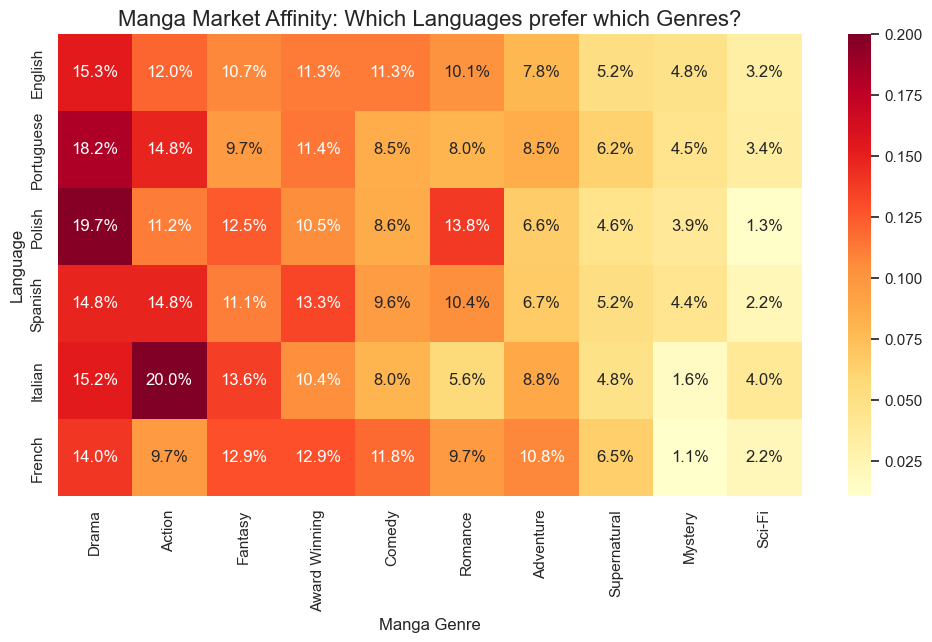

In [281]:
#Top 6 languages including French and checking the affinity mapping 
top_langs = affinity_df['Languages'].value_counts().nlargest(6).index
top_genres = affinity_df['Genres'].value_counts().nlargest(10).index
final_map = affinity_pct.loc[top_langs, top_genres]

plt.figure(figsize=(12, 6))
sns.heatmap(final_map, annot=True, cmap="YlOrRd", fmt=".1%")

plt.title('Manga Market Affinity: Which Languages prefer which Genres?', fontsize=16)
plt.ylabel('Language')
plt.xlabel('Manga Genre')
plt.show()

In [362]:
#[Manga/Merch/Anime combined Dataframe]
#Create a unified Studio Strength DF
manga_merch_combined = merch_anime_df.merge(
    manga_studio_df[['Anime_ID', 'Genres', 'Languages', 'Streaming', 'Award_count', 'Language_count', 'Studios_y', 'Genres']], 
    on='Anime_ID', 
    how='left'
)
manga_merch_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anime_ID            247 non-null    int64  
 1   Title               247 non-null    object 
 2   Originated_From     247 non-null    int64  
 3   Story_DNA           247 non-null    object 
 4   Popularity_Rank     247 non-null    int64  
 5   Score               247 non-null    float64
 6   Reach_Members       247 non-null    int64  
 7   Loyalty_Favourites  247 non-null    int64  
 8   Main_Genre          247 non-null    int64  
 9   Studios             247 non-null    int64  
 10  Producers           247 non-null    object 
 11  Licensors           247 non-null    object 
 12  Episodes            246 non-null    float64
 13  Airing_Year         213 non-null    float64
 14  Rating              0 non-null      float64
 15  Long_Tail_Astudio   247 non-null    int64  
 16  is_hit  

In [369]:
# Prioritising the descriptive studio string over the ID
manga_merch_combined['Studios_Final'] = manga_merch_combined['Studios_y'].fillna('Unknown')

#Filling NaN in metrics to ensure global_power calculation works
manga_merch_combined['Merch_quantity'] = manga_merch_combined['Merch_quantity'].fillna(0)
manga_merch_combined['Language_count'] = manga_merch_combined['Language_count'].fillna(1) # Assume at least 1 language
manga_merch_combined['is_netflix'] = manga_merch_combined['Streaming'].str.contains('netflix', case=False, na=False).astype(int)

#Defining the Global Power Score (Normalized)
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

manga_merch_combined['loyalty_ratio'] = manga_merch_combined['Loyalty_Favourites'] / manga_merch_combined['Reach_Members']
manga_merch_combined['global_power'] = (
    normalize(manga_merch_combined['loyalty_ratio']) + 
    normalize(manga_merch_combined['Merch_quantity']) + 
    normalize(manga_merch_combined['Language_count']) + 
    manga_merch_combined['is_netflix']
)
manga_merch_combined.head(1)

,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,...,Languages,Streaming,Award_count,Language_count,Studios_y,Genres,Studios_Final,is_netflix,loyalty_ratio,global_power
0,52991,Sousou no Frieren,0,During their decade-long quest to defeat the D...,114,9.28,1314756,82922,0,0,...,"English, Polish",viz,2.0,2.0,Madhouse,"Adventure, Award Winning, Drama, Fantasy",Madhouse,0,0.06307,0.767566


In [370]:
#Genres had duplicates, combining them 
manga_merch_combined = manga_merch_combined.loc[:, ~manga_merch_combined.columns.duplicated()]

#Creating the weighted dataframe 
df_weighted = manga_merch_combined.copy()
df_weighted['Genres'] = df_weighted['Genres'].fillna('').astype(str)

#Exploding 
df_weighted['Genres_List'] = df_weighted['Genres'].str.split(', ')
df_exploded = df_weighted.explode('Genres_List')

#Getting rid of white spaces 
df_exploded['Genres_List'] = df_exploded['Genres_List'].str.strip()

#Filtering genres 
exclude_list = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love', 'None', '']
df_filtered = df_exploded[~df_exploded['Genres_List'].isin(exclude_list)]

#Pivoting by Global Power
studio_power_pivot = df_filtered.pivot_table(
    index='Studios_Final', 
    columns='Genres_List', 
    values='global_power', 
    aggfunc='sum'
).fillna(0)

print("Pivot Table Created Successfully!")
print(studio_power_pivot.head())

Pivot Table Created Successfully!
Genres_List              Action  Adventure  Award Winning    Comedy     Drama  \
Studios_Final                                                                   
8bit                   0.000000   0.000000       1.305884  0.000000  0.000000   
A-1 Pictures           0.399688   0.000000       1.036392  0.831231  1.645152   
Artland                0.000000   0.000000       0.485377  0.000000  0.000000   
Bandai Namco Pictures  0.518537   0.000000       0.000000  0.518537  0.000000   
Bones                  1.637310   0.597246       0.949800  1.072187  1.097202   

Genres_List             Fantasy  Horror   Mystery   Romance    Sci-Fi  \
Studios_Final                                                           
8bit                   1.263034     0.0  0.000000  0.000000  0.000000   
A-1 Pictures           0.000000     0.0  1.724848  1.485239  0.690981   
Artland                0.485377     0.0  0.485377  0.000000  0.000000   
Bandai Namco Pictures  0.000000  

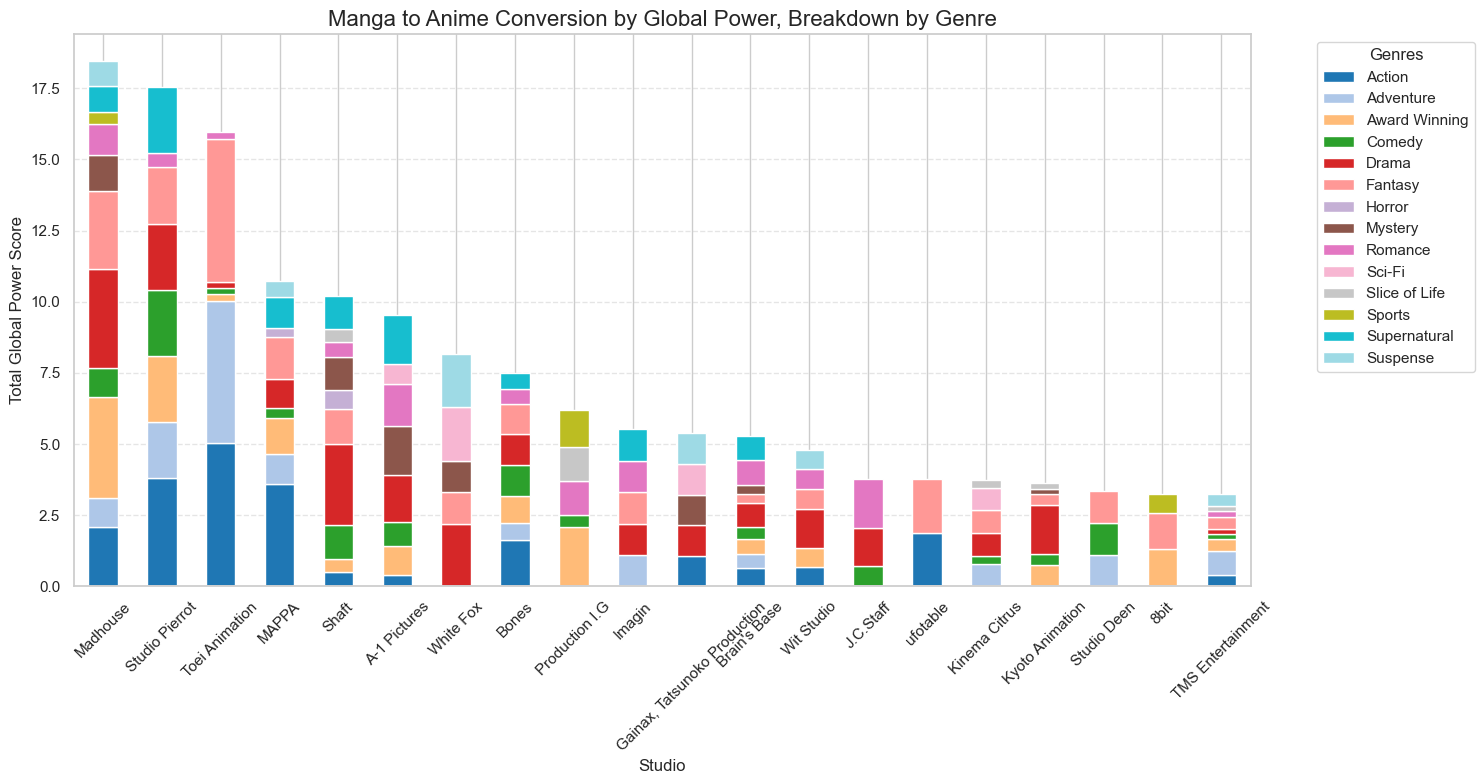

In [375]:
#Sorting by total power first based on pivot table 
studio_power_pivot['Total'] = studio_power_pivot.sum(axis=1)
plot_df = studio_power_pivot.sort_values('Total', ascending=False).drop(columns='Total')

#Focusing on top 15 
plot_df = plot_df.head(20) 

#Stacked chart 
plot_df.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='tab20')
plt.title('Manga to Anime Conversion by Global Power, Breakdown by Genre', fontsize=16)
plt.xlabel('Studio', fontsize=12)
plt.ylabel('Total Global Power Score', fontsize=12)
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('studio_genre_power_chart.png')
plt.show()

In [397]:
#How language count correlates with global power of its animated version 

# Count how many shows each studio has
studio_counts = manga_merch_combined['Studios_Final'].value_counts()

#Studio with at least 5 shows 
prolific_studios = studio_counts[studio_counts >= 5].index

#filtered the studio by above 
filtered_df = manga_merch_combined[manga_merch_combined['Studios_Final'].isin(prolific_studios)]

#Correlation between langugae count and global power 
studio_corrs_clean = (
    filtered_df.groupby('Studios_Final')[['global_power', 'Language_count']]
    .corr()
    .iloc[0::2, -1]
    .reset_index()
    .drop(columns='level_1')
    .rename(columns={'Language_count': 'correlation'})
    .sort_values(by='correlation', ascending=False)
)

print(studio_corrs_clean)


plt.show

     Studios_Final  correlation
3  Kyoto Animation     0.919628
2     Brain's Base     0.791596
1            Bones     0.582163
5         Madhouse     0.563666
0     A-1 Pictures     0.301896
4            MAPPA     0.210676
6            Shaft    -0.616572
7          Unknown          NaN


In [485]:
#Separating the Anime Originals from the rest 
merch_anime_df['loyalty_ratio'] = merch_anime_df['Loyalty_Favourites'] / merch_anime_df['Reach_Members']
merch_anime_df['globalisation'] = (normalize(merch_anime_df['loyalty_ratio']) + normalize(merch_anime_df['Merch_quantity'])

_IncompleteInputError: incomplete input (2477908610.py, line 3)

In [433]:
#calculating globalisation column
merch_anime_df['loyalty_ratio'] = merch_anime_df['Loyalty_Favourites'] / merch_anime_df['Reach_Members']

def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

norm_loyalty = min_max_normalize(merch_anime_df['loyalty_ratio'])
norm_merch = min_max_normalize(merch_anime_df['Merch_quantity'])

merch_anime_df['globalisation'] = norm_loyalty + norm_merch

merch_anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anime_ID            230 non-null    int64  
 1   Title               230 non-null    object 
 2   Originated_From     230 non-null    int64  
 3   Story_DNA           230 non-null    object 
 4   Popularity_Rank     230 non-null    int64  
 5   Score               230 non-null    float64
 6   Reach_Members       230 non-null    int64  
 7   Loyalty_Favourites  230 non-null    int64  
 8   Main_Genre          230 non-null    int64  
 9   Studios             230 non-null    int64  
 10  Producers           230 non-null    object 
 11  Licensors           230 non-null    object 
 12  Episodes            229 non-null    float64
 13  Airing_Year         199 non-null    float64
 14  Rating              0 non-null      float64
 15  Long_Tail_Astudio   230 non-null    int64  
 16  is_hit  

***Machine Learning Models with the New Globalisation Metrics ***

In [460]:
#Anime Originals 
originals_df = merch_anime_df[merch_anime_df['Originated_From'] == 4]

#All other Animations 
adaptations_df = merch_anime_df[merch_anime_df['Originated_From'] != 4]

In [472]:
##[All Other Studios DataFrame]
#1 : Separating Features from Target Column in Surpervised Machine Learning 
features = adaptations_df.drop(columns=["globalisation","Title", "merge_key","Episodes", "Airing_Year", "Rating", "Anime_ID", "Loyalty_Favourites","is_hit", "Reach_Members", "Title", "Story_DNA", "Long_Tail_Astudio", "Producers", "Licensors", "Merch_quantity"
], errors='ignore')
target = adaptations_df["globalisation"]
if features.columns[5] == 'Title' or features.dtypes[features.columns[5]] == 'object':
    features = features.drop(features.columns[5], axis=1)

In [473]:
#Surpervised Machine Learning Trial 
#Spliting Test & Train 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [474]:
#Random Forest Regressor to predict the Globalisation Rate 
model = RandomForestRegressor()
model.fit(X_train, y_train)

# 4. Check importance
importances = model.feature_importances_
print(f"Model Score (R^2): {model.score(X_test, y_test)}")

Model Score (R^2): 0.6246393874721569


In [468]:
#
print(f"Model Reliability (R^2): {model.score(X_test, y_test):.4f}")

#Feature Importance
feature_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance for non-Originals (What drives Globalisation?) ---")
print(feature_results)

Model Reliability (R^2): 0.6118

--- Feature Importance for non-Originals (What drives Globalisation?) ---
           Feature  Importance
5    loyalty_ratio    0.532575
1  Popularity_Rank    0.297884
2            Score    0.069131
3       Main_Genre    0.046838
4          Studios    0.041656
0  Originated_From    0.011917


In [481]:
##[Originals DataFrame]
#1 : Separating Features from Target Column in Surpervised Machine Learning 
features = originals_df.drop(columns=["globalisation","Title", "merge_key","Episodes", "Airing_Year", "Rating", "Anime_ID", "Loyalty_Favourites","is_hit", "Reach_Members", "Title", "Story_DNA", "Long_Tail_Astudio", "Producers", "Licensors", "Merch_quantity"
], errors='ignore')
target = originals_df["globalisation"]
if features.columns[5] == 'Title' or features.dtypes[features.columns[5]] == 'object':
    features = features.drop(features.columns[5], axis=1)

In [482]:
#Surpervised Machine Learning Trial 
#Spliting Test & Train 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [483]:
#Random Forest Regressor to predict the Globalisation Rate 
model = RandomForestRegressor()
model.fit(X_train, y_train)

# 4. Check importance
importances = model.feature_importances_
print(f"Model Score (R^2): {model.score(X_test, y_test)}")

Model Score (R^2): 0.9482950154974439
